
=== 3-way ANOVA (Type II) ===
                        sum_sq    df             F         PR(>F)
C(gender)         8.851106e+08   1.0    869.610220  4.760028e-165
C(age)            2.238880e+10  40.0    549.918039   0.000000e+00
C(occupation)     1.522341e+11   4.0  37392.032711   0.000000e+00
C(gender):C(age)  2.034050e+08  40.0      4.996072   4.428012e-22

Sex × Age interaction p = 4.43e-22  →  YES – the gender gap differs by age.


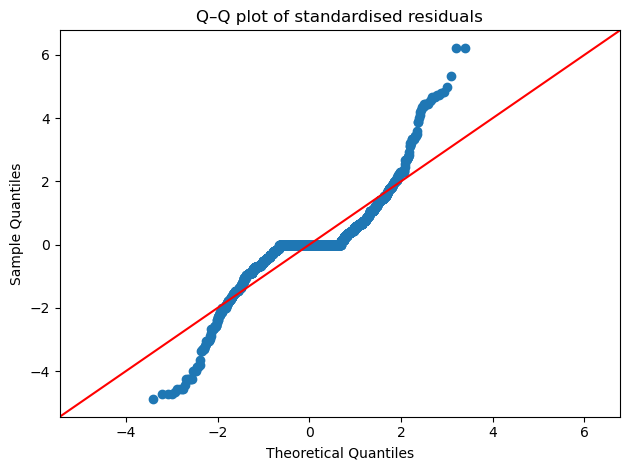

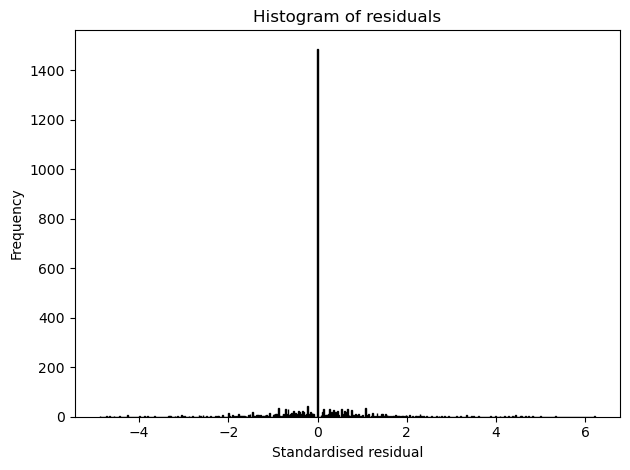

/var/folders/xf/3h6xnmdj0jg__mms2zt6r6wc0000gn/T/ipykernel_32142/1497616555.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tbl = (df.groupby(["age", "gender"])["middle_salary"]


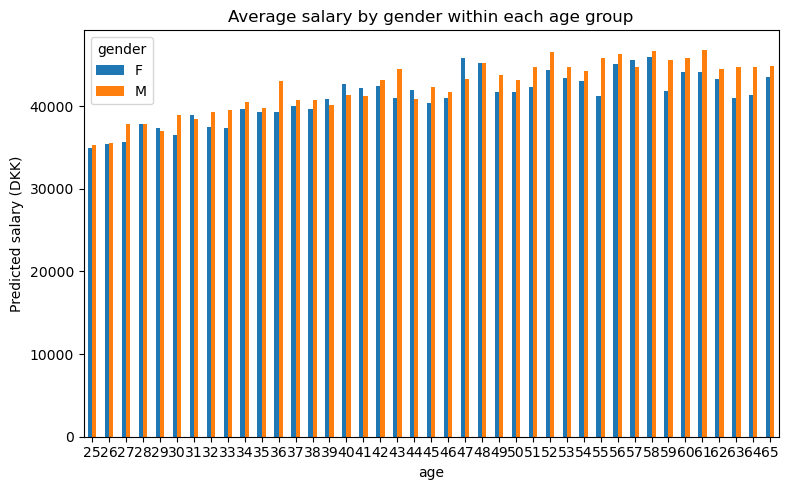

In [1]:
# gender_age_job_anova.py  --------------------------------------------
# Needs: pandas, statsmodels, matplotlib, scipy
# ---------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np

CSV = "/Users/vitusthaulow/Documents/GitHub/Project-in-Stat.-Eval.-02445/salaries_3000.csv"

# 1. Load the four columns we need
cols = ["gender", "age", "occupation", "middle_salary"]
df   = pd.read_csv(CSV, usecols=cols)

# 2. Treat grouping variables as factors
for col in ["gender", "age", "occupation"]:
    df[col] = df[col].astype("category")

# 3. Three-way ANOVA (Type II)
model = smf.ols("middle_salary ~ C(gender)*C(age)*C(occupation)", data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== 3-way ANOVA (Type II) ===")
print(anova.loc[["C(gender)", "C(age)", "C(occupation)", "C(gender):C(age)"]])

p = anova.loc["C(gender):C(age)", "PR(>F)"]
msg = "YES – the gender gap differs by age." if p < 0.05 else \
      "No – the gap is roughly constant across ages."
print(f"\nSex × Age interaction p = {p:.3g}  →  {msg}")

# 3 b. Residual normality diagnostics ---------------------------------
resid   = model.resid
resid_z = (resid - resid.mean()) / resid.std(ddof=1)       # standardiseret

# Q–Q-plot
sm.qqplot(resid_z, line="45")
plt.title("Q–Q plot of standardised residuals")
plt.tight_layout()
plt.show()

# Histogram
plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardised residual")
plt.ylabel("Frequency")
plt.title("Histogram of residuals")
plt.tight_layout()
plt.show()

# 4. Bar-plot with fixed colours --------------------------------------
colour_map = {"F": "#1f77b4",    # blue
              "M": "#ff7f0e"}    # orange

mean_tbl = (df.groupby(["age", "gender"])["middle_salary"]
              .mean()
              .unstack())        # rows = age, cols = gender

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(8, 5), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_ylabel("Predicted salary (DKK)")
ax.set_title("Average salary by gender within each age group")
ax.legend(title="gender")
plt.tight_layout()
plt.show()


=== 2-way ANOVA + alder ===
                               sum_sq   df            F        PR(>F)
C(occupation)            1.536417e+11  4.0  7752.279487  0.000000e+00
C(gender)                8.881285e+08  1.0   179.248704  9.975851e-40
C(occupation):C(gender)  1.231663e+09  4.0    62.145863  1.729679e-50


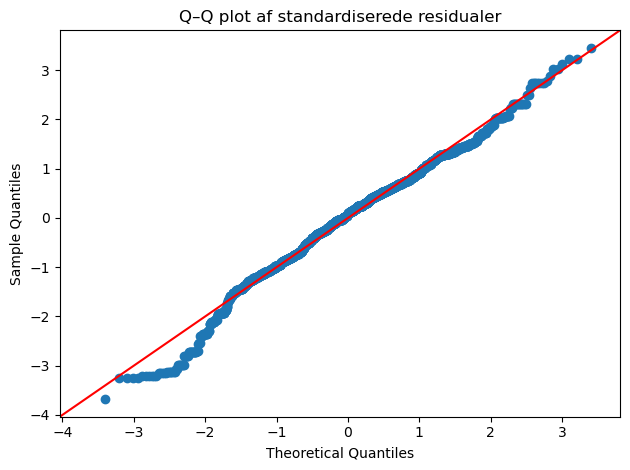

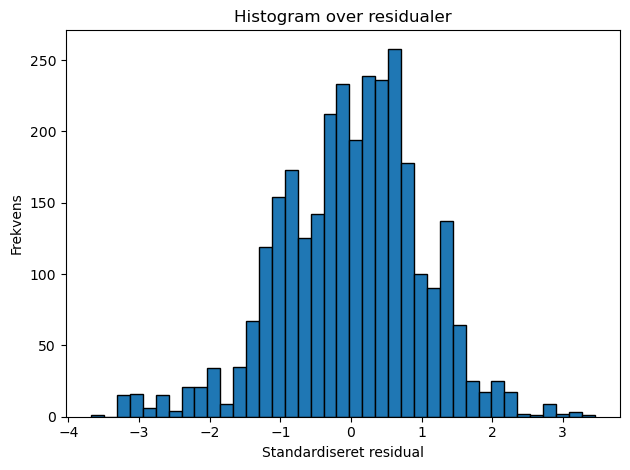

/var/folders/xf/3h6xnmdj0jg__mms2zt6r6wc0000gn/T/ipykernel_32142/2031942825.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tbl = (df.groupby(["occupation", "gender"])["middle_salary"]


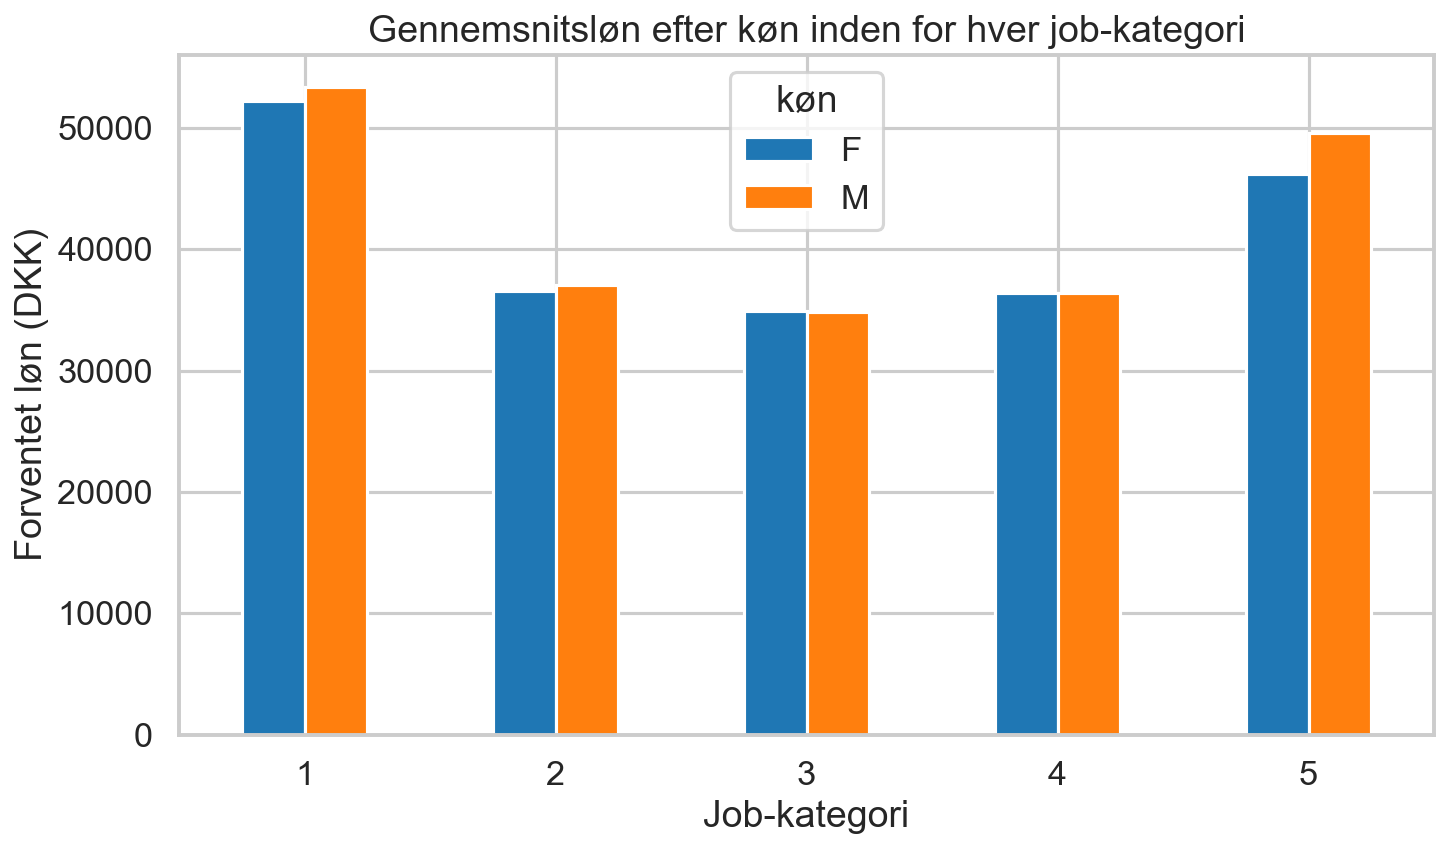

In [2]:
# job_gender_anova.py  -------------------------------------------------
# Kontrollerer:
#   1) Ligger de fem job-kategorier på forskellige lønniveauer?
#   2) Varierer kønsforskellen fra job til job?
# Indeholder desuden residual-normalitets­diagnostik.
# ---------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

CSV = "/Users/vitusthaulow/Documents/GitHub/Project-in-Stat.-Eval.-02445/salaries_3000.csv"

# ---------- 1. Load & prep -------------------------------------------
cols = ["gender", "age", "occupation", "middle_salary"]
df   = pd.read_csv(CSV, usecols=cols)

for col in ["gender", "age", "occupation"]:
    df[col] = df[col].astype("category")

# ---------- 2. ANOVA (occupation × gender, kontrolleret for alder) ----
model = smf.ols("middle_salary ~ C(occupation)*C(gender) + C(age)", data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== 2-way ANOVA + alder ===")
print(anova.loc[["C(occupation)", "C(gender)", "C(occupation):C(gender)"]])

# ---------- 3. Residual-normalitet ------------------------------------
resid   = model.resid
resid_z = (resid - resid.mean()) / resid.std(ddof=1)

sm.qqplot(resid_z, line="45")
plt.title("Q–Q plot af standardiserede residualer")
plt.tight_layout()
plt.show()

plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardiseret residual")
plt.ylabel("Frekvens")
plt.title("Histogram over residualer")
plt.tight_layout()
plt.show()

# ---------- 4. Bar-plot (samme look-and-feel) -------------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 150

colour_map = {"F": "#1f77b4", "M": "#ff7f0e"}     # blå / orange

mean_tbl = (df.groupby(["occupation", "gender"])["middle_salary"]
              .mean()
              .unstack())

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(10, 6), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_xlabel("Job-kategori")
ax.set_ylabel("Forventet løn (DKK)")
ax.set_title("Gennemsnitsløn efter køn inden for hver job-kategori")
ax.legend(title="køn")

plt.tight_layout()
plt.show()

In [10]:
# ---------- 3. Residual-normalitet ------------------------------------
resid   = model.resid
resid_z = (resid - resid.mean()) / resid.std(ddof=1)

# --- Shapiro–Wilk test ------------------------------------------------
w_stat, p_val = st.shapiro(resid)          # eller resid_z – giver samme resultat
print(f"\nShapiro–Wilk normalitetstest:")
print(f"  W = {w_stat:.3f}   p = {p_val:.4g}")


Shapiro–Wilk normalitetstest:
  W = 0.867   p = 2.283e-44


In [12]:
# --- hvor mange observationer i hver occupation × gender-celle? ----------
cell_sizes = (
    df.groupby(["occupation", "gender"])
      .size()
      .unstack(fill_value=0)        # pæn 2D-tabel
)

display(cell_sizes)                 # Jupyter viser en flot tabel
print("\nMindste celle-størrelse:", cell_sizes.min().min())

gender,F,M
occupation,,
1,292,289
2,295,288
3,293,292
4,292,295
5,291,293



Mindste celle-størrelse: 288


In [14]:
robust = model.get_robustcov_results(cov_type="HC3")
print(robust.summary())

                            OLS Regression Results                            
Dep. Variable:          middle_salary   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     4365.
Date:                Thu, 12 Jun 2025   Prob (F-statistic):               0.00
Time:                        11:09:01   Log-Likelihood:                -25062.
No. Observations:                2920   AIC:                         5.028e+04
Df Residuals:                    2840   BIC:                         5.076e+04
Df Model:                          79                                         
Covariance Type:                  HC3                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

/usr/local/Caskroom/miniconda/base/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 79, but rank is 64
  warnings.warn('covariance of constraints does not have full '


In [19]:
# ------------------------------------------------------------
# Interaktionsled: F- og p-værdier (Type-II ANOVA)
# ------------------------------------------------------------
import statsmodels.api as sm

# Beregn ANOVA-tabel hvis den mangler
anova_tbl = sm.stats.anova_lm(model, typ=2)

# Udskriv kun interaktioner (rækker med ':')
interactions = anova_tbl[anova_tbl.index.str.contains(":")]

if interactions.empty:
    print("Modellen indeholder ingen interaktionsled.")
else:
    print("=== Interaktionseffekter (Type II ANOVA) ===")
    display(interactions[["F", "PR(>F)"]].rename(columns={"PR(>F)": "p-værdi"}))

=== Interaktionseffekter (Type II ANOVA) ===


,F,p-værdi
C(gender):C(age_band),8.209883,6.128827e-10
C(gender):C(occupation),197.039048,2.809172e-149
C(age_band):C(occupation),213.987551,0.000000e+00
C(gender):C(age_band):C(occupation),11.702340,1.264875e-49



=== 3-way ANOVA (Type II) ===
                             sum_sq   df             F         PR(>F)
C(gender)              8.723560e+08  1.0    508.229946  1.143196e-103
C(age_band)            2.061128e+10  7.0   1715.432057   0.000000e+00
C(occupation)          1.495137e+11  4.0  21776.463536   0.000000e+00
C(gender):C(age_band)  9.864351e+07  7.0      8.209883   6.128827e-10

Køn × Alders-bånd interaktion p = 6.13e-10  →  YES – kønsforskellen varierer mellem alders-intervallerne.


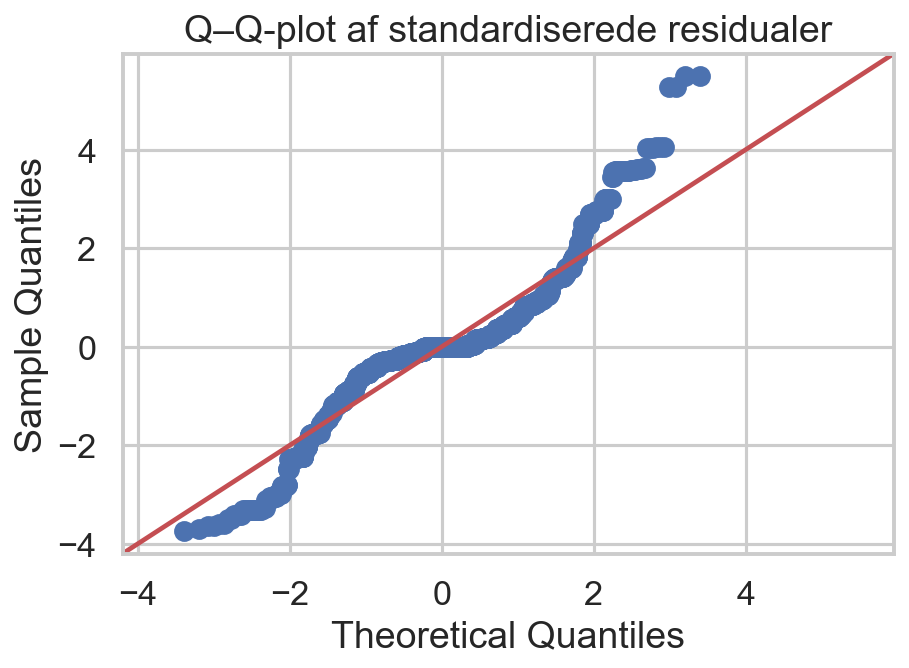

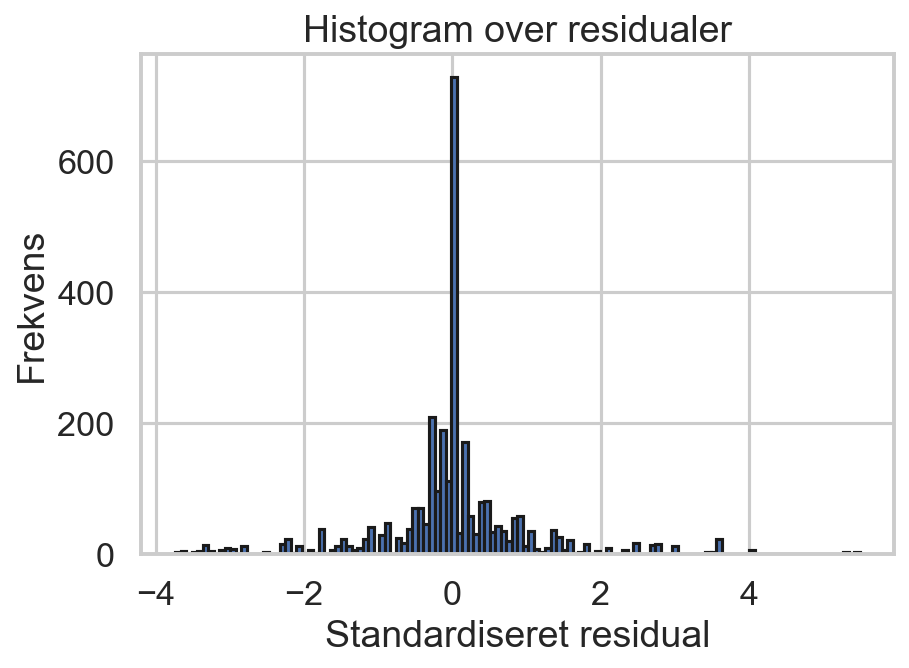

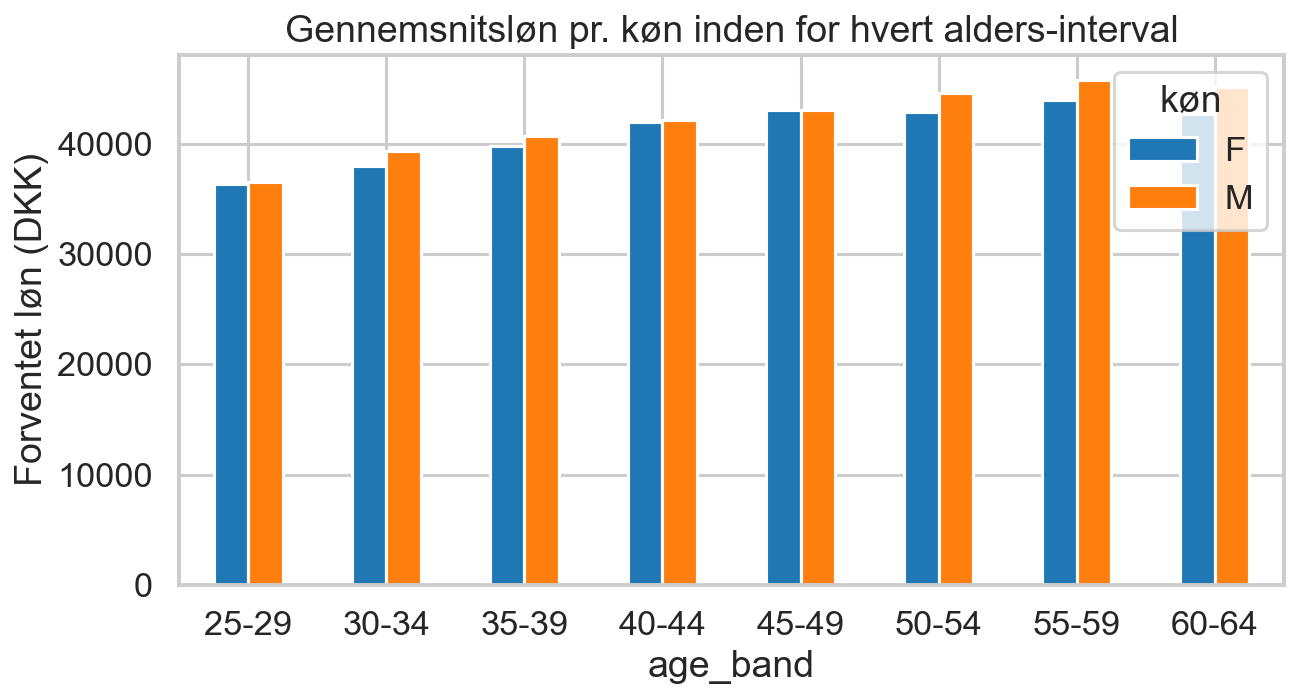

In [13]:
# gender_age_job_anova_binned.py  --------------------------------------
# Kræver: pandas, statsmodels, matplotlib, scipy
# ---------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

CSV = "/Users/vitusthaulow/Documents/GitHub/Project-in-Stat.-Eval.-02445/salaries_3000.csv"

# 1. Hent de fire variable vi skal bruge
cols = ["gender", "age", "occupation", "middle_salary"]
df   = pd.read_csv(CSV, usecols=cols)

# 2. Definér alders-intervaller (her 5-års-spænd fra 25 år og opefter)
#    Tilpas bins/labels hvis du vil have andre intervaller
bins   = list(range(25, int(df["age"].max()) + 5, 5))      # 25, 30, 35, …
labels = [f"{b}-{b+4}" for b in bins[:-1]]                 # 25-29, 30-34, …
df["age_band"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# 3. Gør grouping-variabler til kategorier
for col in ["gender", "age_band", "occupation"]:
    df[col] = df[col].astype("category")

# 4. Tre-vejs ANOVA (Type II) med alders-bånd
model = smf.ols("middle_salary ~ C(gender)*C(age_band)*C(occupation)", data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== 3-way ANOVA (Type II) ===")
print(anova.loc[["C(gender)", "C(age_band)", "C(occupation)", "C(gender):C(age_band)"]])

p = anova.loc["C(gender):C(age_band)", "PR(>F)"]
msg = "YES – kønsforskellen varierer mellem alders-intervallerne." if p < 0.05 else \
      "Nej – forskellen er omtrent konstant på tværs af intervaller."
print(f"\nKøn × Alders-bånd interaktion p = {p:.3g}  →  {msg}")

# 5. Residual-diagnostik ------------------------------------------------
resid   = model.resid
resid_z = (resid - resid.mean()) / resid.std(ddof=1)

sm.qqplot(resid_z, line="45")
plt.title("Q–Q-plot af standardiserede residualer")
plt.tight_layout()
plt.show()

plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardiseret residual")
plt.ylabel("Frekvens")
plt.title("Histogram over residualer")
plt.tight_layout()
plt.show()

# 6. Søjlediagram med faste farver -------------------------------------
colour_map = {"F": "#1f77b4",    # blå
              "M": "#ff7f0e"}    # orange

mean_tbl = (df.groupby(["age_band", "gender"])["middle_salary"]
              .mean()
              .unstack())        # rækker = alders-bånd, kolonner = køn

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(9, 5), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_ylabel("Forventet løn (DKK)")
ax.set_title("Gennemsnitsløn pr. køn inden for hvert alders-interval")
ax.legend(title="køn")
plt.tight_layout()
plt.show()

=== 3-vejs ANOVA (Type II) ===
                             sum_sq   df             F         PR(>F)
C(gender)              8.723560e+08  1.0    508.229946  1.143196e-103
C(age_band)            2.061128e+10  7.0   1715.432057   0.000000e+00
C(occupation)          1.495137e+11  4.0  21776.463536   0.000000e+00
C(gender):C(age_band)  9.864351e+07  7.0      8.209883   6.128827e-10

--- Antagelsestest ---
Shapiro-Wilk          : W = 0.867, p = 2.283e-44
Levene (mean-center)  : F = 37.833, p = 0
Brown-Forsythe        : F = 11.213, p = 4.753e-116
Breusch-Pagan         : LM = 892.16, p = 6.297e-138
Durbin-Watson         : DW = 1.974


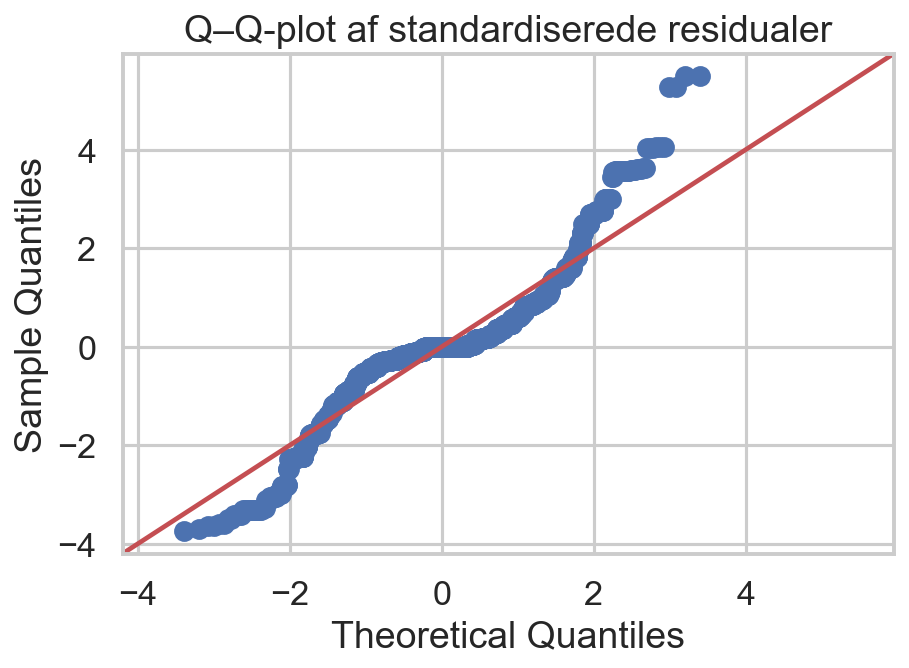

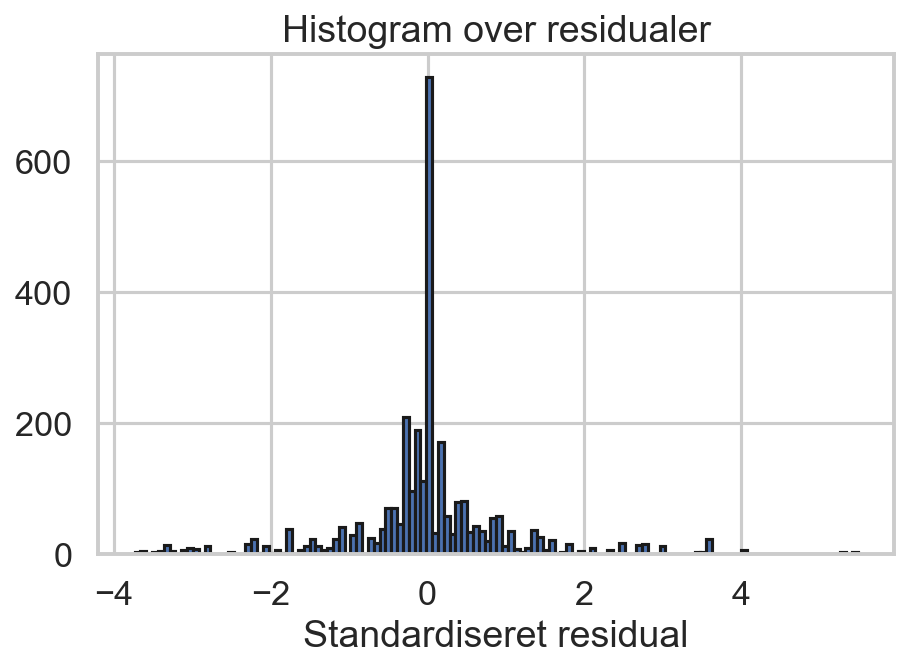

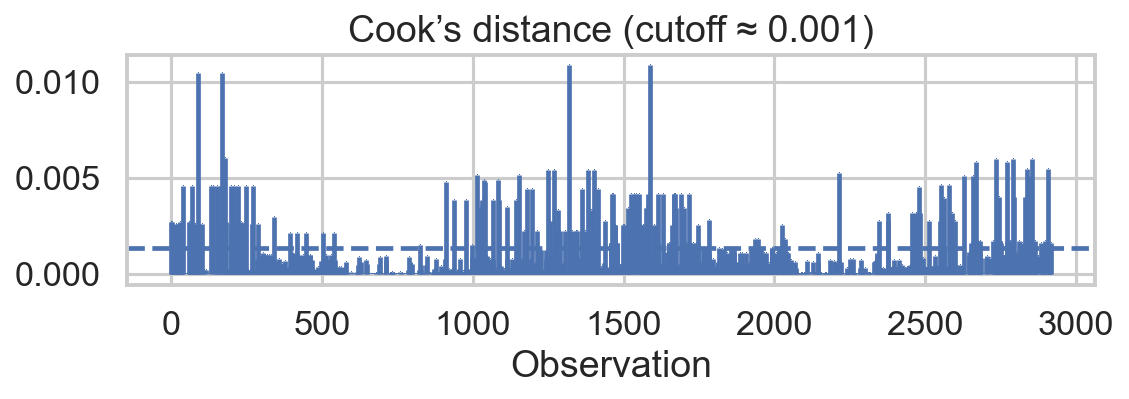


218 observation(er) ligger over Cook’s-cutoff.

--- Tukey HSD (alder×køn) ---
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
 group1  group2  meandiff  p-adj    lower      upper    reject
--------------------------------------------------------------
25-29_F 25-29_M   194.9309    1.0  -2549.424  2939.2858  False
25-29_F 30-34_F  1562.4247 0.8483 -1174.5056  4299.3551  False
25-29_F 30-34_M  2956.6318 0.0166   254.7879  5658.4757   True
25-29_F 35-39_F   3428.576 0.0023   665.0149  6192.1371   True
25-29_F 35-39_M  4351.0447    0.0   1635.558  7066.5315   True
25-29_F 40-44_F  5627.6163    0.0  2925.7724  8329.4602   True
25-29_F 40-44_M  5774.4258    0.0  3041.1545  8507.6971   True
25-29_F 45-49_F  6662.5134    0.0  3932.8665  9392.1602   True
25-29_F 45-49_M  6713.4786    0.0  3945.9612   9480.996   True
25-29_F 50-54_F  6536.9136    0.0  3781.1483  9292.6789   True
25-29_F 50-54_M  8233.1215    0.0  5553.9919 10912.2511   True
25-29_F 55-59_F  7616.7753    0.0  4921

In [8]:
# ============================================================
# 3-vejs ANOVA + antagelsestest  ▸  kør i én Jupyter-celle
# ------------------------------------------------------------
#   Model : middle_salary ~ gender × age_band × occupation
#   Afh.  : pandas, numpy, scipy, statsmodels, matplotlib
#           pip install pandas numpy scipy statsmodels matplotlib
# ============================================================

# ---------- KONFIGURATION -----------------------------------
CSV         = "salaries_3000.csv"   # ← angiv fuld eller relativ sti
BIN_WIDTH   = 5                     # år pr. alders-interval (fx 5 = 25-29, 30-34 …)
START_AGE   = 25                    # første aldersgrænse
RUN_POSTHOC = True                  # True ▸ udfør Tukey HSD post-hoc
SHOW_PLOTS  = True                  # True ▸ vis residual- og Cook’s-plots
# -------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import shapiro, levene
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.stats.multicomp as mc

# ---------- Data & model ------------------------------------
cols = ["gender", "age", "occupation", "middle_salary"]
df   = pd.read_csv(CSV, usecols=cols)

bins   = list(range(START_AGE, int(df["age"].max()) + BIN_WIDTH, BIN_WIDTH))
labels = [f"{b}-{b+BIN_WIDTH-1}" for b in bins[:-1]]
df["age_band"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

for col in ["gender", "age_band", "occupation"]:
    df[col] = df[col].astype("category")

# Smid evt. observationer under START_AGE
df = df.dropna(subset=["age_band"])

model = smf.ols("middle_salary ~ C(gender)*C(age_band)*C(occupation)", data=df).fit()
anova_tbl = sm.stats.anova_lm(model, typ=2)

print("=== 3-vejs ANOVA (Type II) ===")
print(anova_tbl.loc[["C(gender)", "C(age_band)",
                     "C(occupation)", "C(gender):C(age_band)"]])

# ---------- Antagelsestest ----------------------------------
print("\n--- Antagelsestest ---")
# Normalitet
w, p = shapiro(model.resid)
print(f"Shapiro-Wilk          : W = {w:.3f}, p = {p:.4g}")

# Homogen varians
groups = df.groupby(["gender", "age_band", "occupation"])["middle_salary"].apply(list)
F_m, p_m  = levene(*groups, center="mean")   # klassisk Levene
F_md, p_md = levene(*groups, center="median")# Brown-Forsythe
print(f"Levene (mean-center)  : F = {F_m:.3f}, p = {p_m:.4g}")
print(f"Brown-Forsythe        : F = {F_md:.3f}, p = {p_md:.4g}")

# Heteroskedasticitet
lm, lm_p, fval, f_p = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan         : LM = {lm:.2f}, p = {lm_p:.4g}")

# Uafhængighed
dw = durbin_watson(model.resid)
print(f"Durbin-Watson         : DW = {dw:.3f}")

# ---------- Plots -------------------------------------------
if SHOW_PLOTS:
    # Standardiserede residualer
    z = (model.resid - model.resid.mean())/model.resid.std(ddof=1)
    sm.qqplot(z, line="45")
    plt.title("Q–Q-plot af standardiserede residualer")
    plt.tight_layout(); plt.show()

    plt.figure()
    plt.hist(z, bins="auto", edgecolor="k")
    plt.xlabel("Standardiseret residual")
    plt.title("Histogram over residualer")
    plt.tight_layout(); plt.show()

    # Cook’s distance
    infl = model.get_influence()
    c, _ = infl.cooks_distance
    cutoff = 4/len(c)
    plt.figure(figsize=(8,3))
    plt.stem(c, markerfmt=",", basefmt=" ")
    plt.axhline(cutoff, ls="--")
    plt.title(f"Cook’s distance (cutoff ≈ {cutoff:.3f})")
    plt.xlabel("Observation")
    plt.tight_layout(); plt.show()
    print(f"\n{(c>cutoff).sum()} observation(er) ligger over Cook’s-cutoff.")

# ---------- Post-hoc ----------------------------------------
if RUN_POSTHOC:
    tmp = df.copy()
    tmp["grp"] = tmp["age_band"].astype(str) + "_" + tmp["gender"].astype(str)
    res = mc.MultiComparison(tmp["middle_salary"], tmp["grp"]).tukeyhsd()
    print("\n--- Tukey HSD (alder×køn) ---")
    print(res.summary())
